# Lab 2 Variant 6


In [13]:
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams["figure.figsize"] = (9, 4.5)

def db(x, floor_db=-160.0):
    """Magnitude to dB with floor to avoid -inf."""
    x = np.asarray(x)
    mag = np.abs(x)
    mag = np.maximum(mag, 10**(floor_db/20))
    return 20*np.log10(mag)

def nextpow2(n):
    return 1 << int(np.ceil(np.log2(int(n))))

def make_window(name, N, beta=8.0):
    """Return common windows. Kaiser uses the 'beta' parameter."""
    name = name.lower()
    if name in ["rect", "rectangular", "boxcar", "none"]:
        return np.ones(N)
    if name == "hann":
        return np.hanning(N)
    if name == "hamming":
        return np.hamming(N)
    if name == "blackman":
        return np.blackman(N)
    if name == "kaiser":
        return np.kaiser(N, beta)
    raise ValueError(f"Unknown window: {name}")

def coherent_gain(w):
    """Coherent gain Gc = mean(w)."""
    w = np.asarray(w)
    return np.sum(w) / len(w)

def fft_mag(x, fs, nfft=None):
    """One-sided FFT magnitude and frequency axis."""
    x = np.asarray(x)
    N = len(x)
    if nfft is None:
        nfft = nextpow2(N) * 8
    X = np.fft.rfft(x, n=nfft)
    f = np.fft.rfftfreq(nfft, d=1/fs)
    return f, np.abs(X)

def plot_time(x, fs, title="", nshow=400):
    N = len(x)
    n = np.arange(N)
    nshow = min(nshow, N)
    t = n[:nshow] / fs
    plt.figure()
    plt.plot(t, x[:nshow])
    plt.grid(True)
    plt.xlabel("Time [s]")
    plt.ylabel("Amplitude")
    plt.title(title)
    plt.show()

def plot_spectra_for_windows(x, fs, N, win_list, title="", fmax=None, normalize_peak=True, beta=8.0):
    """Plot normalized spectra (dB) for a set of windows."""
    plt.figure()
    for nm in win_list:
        w = make_window(nm, N, beta=beta)
        f, X = fft_mag(x*w, fs)
        Y = X
        if normalize_peak:
            Y = Y / np.max(Y)
        plt.plot(f, db(Y), label=(nm if nm != "kaiser" else f"kaiser(beta={beta})"))
    plt.grid(True)
    plt.xlabel("Frequency [Hz]")
    plt.ylabel("Magnitude [dB]")
    if fmax is not None:
        plt.xlim(0, fmax)
    plt.ylim(-140, 5)
    plt.title(title)
    plt.legend()
    plt.show()


# Solution - Variant 6

**Parameters:**

| Parameter | Value |
|---|---|
| $f_1$ | 600 Hz |
| $f_2$ | 600.25 Hz |
| $f_3$ | 599.75 Hz |
| $A_1 = \|x[k]\|_{\max}$ | 3 |
| $A_2 = 0.1 A_1$ | 0.3 |
| $A_3 = 0.01 A_1$ | 0.03 |
| $f_s$ | 800 Hz |
| $N$ | 2000 |
| $df = f_s/N$ | 0.4 Hz |

Signal:
$$x[k] = A_1 \sin\!\left(2\pi\frac{f_1}{f_s}k\right) + A_2 \sin\!\left(2\pi\frac{f_2}{f_s}k\right) + A_3 \sin\!\left(2\pi\frac{f_3}{f_s}k\right), \quad 0 \le k < N$$


fs=800.0 Hz,  N=2000,  df=0.4000 Hz
f1=600.0 Hz -> alias 200.00 Hz
f2=600.25 Hz -> alias 199.7500 Hz
f3=599.75 Hz -> alias 200.2500 Hz
A1=3.0,  A2=0.30000000000000004,  A3=0.03
A2/A1 = 0.10 (-20.0 dB),  A3/A1 = 0.010 (-40.0 dB)


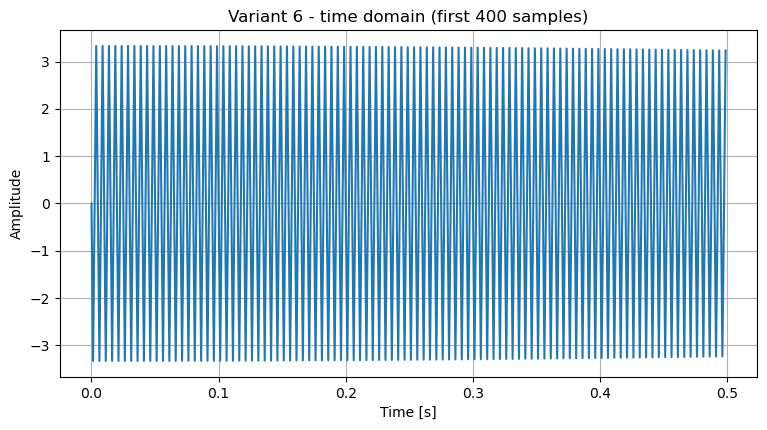

In [14]:
# ── Variant 6 - parameters ────────────────────────────────────────────────────
fs  = 800.0
N   = 2000
f1  = 600.0      # Hz  (aliases to 200 Hz)
f2  = 600.25     # Hz  (aliases to 199.75 Hz)
f3  = 599.75     # Hz  (aliases to 200.25 Hz)
A1  = 3.0
A2  = 0.1 * A1   # 0.3
A3  = 0.01 * A1  # 0.03
df  = fs / N

print(f"fs={fs} Hz,  N={N},  df={df:.4f} Hz")
print(f"f1={f1} Hz -> alias {fs-f1:.2f} Hz")
print(f"f2={f2} Hz -> alias {fs-f2:.4f} Hz")
print(f"f3={f3} Hz -> alias {fs-f3:.4f} Hz")
print(f"A1={A1},  A2={A2},  A3={A3}")
print(f"A2/A1 = {A2/A1:.2f} ({20*np.log10(A2/A1):.1f} dB),  "
      f"A3/A1 = {A3/A1:.3f} ({20*np.log10(A3/A1):.1f} dB)")

# Signal generation (sine wave as per task description)
k = np.arange(N)
x = (A1 * np.sin(2*np.pi*f1/fs * k)
   + A2 * np.sin(2*np.pi*f2/fs * k)
   + A3 * np.sin(2*np.pi*f3/fs * k))

# Time domain - first 400 samples
plot_time(x, fs, title="Variant 6 - time domain (first 400 samples)", nshow=400)


## Plot 1 – DFT spectra for different windows (dB scale, normalized values)


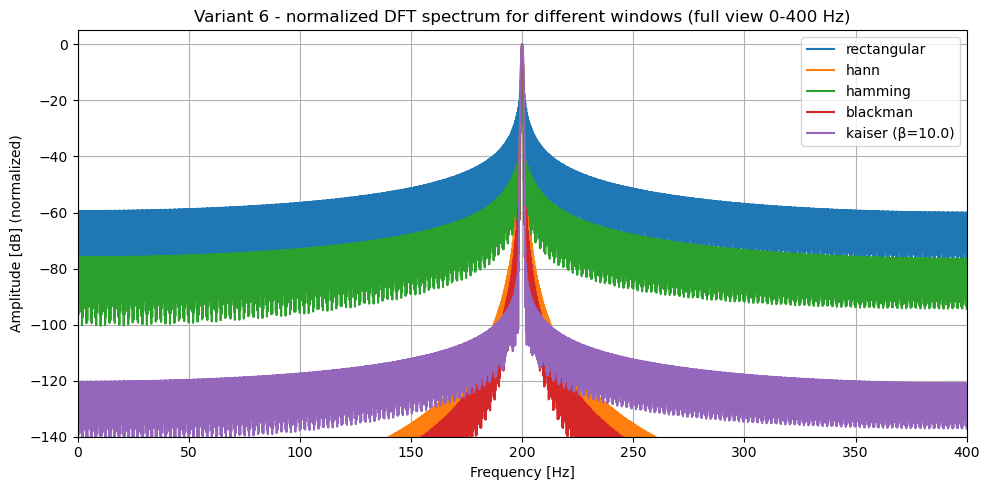

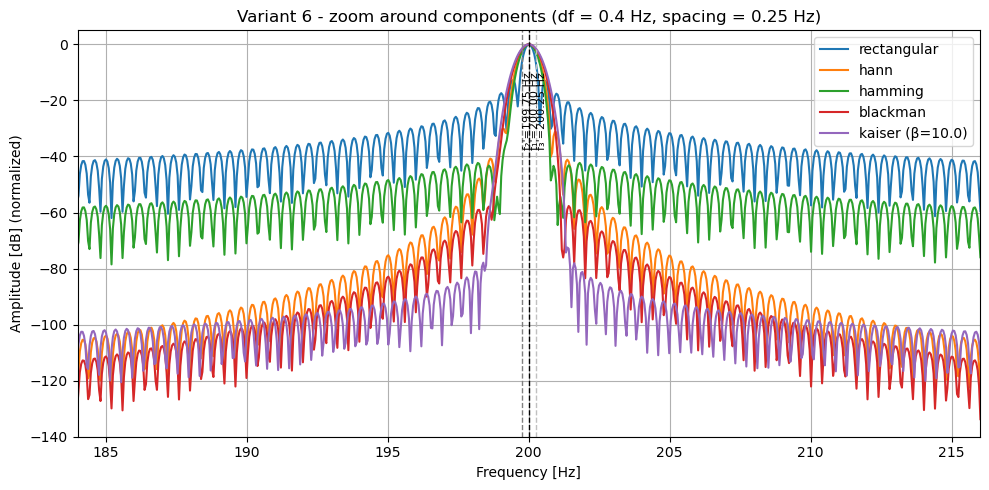

In [15]:
win_list = ["rectangular", "hann", "hamming", "blackman", "kaiser"]
beta = 10.0

# ── Full spectrum (0 … fs/2) ──────────────────────────────────────────────────
plt.figure(figsize=(10, 5))
for nm in win_list:
    w = make_window(nm, N, beta=beta)
    f, X = fft_mag(x * w, fs)
    Y = X / np.max(X)  # normalize to 0 dB at peak
    lbl = nm if nm != "kaiser" else f"kaiser (β={beta})"
    plt.plot(f, db(Y), label=lbl)

plt.grid(True)
plt.xlabel("Frequency [Hz]")
plt.ylabel("Amplitude [dB] (normalized)")
plt.title("Variant 6 - normalized DFT spectrum for different windows (full view 0-400 Hz)")
plt.xlim(0, fs / 2)
plt.ylim(-140, 5)
plt.legend()
plt.tight_layout()
plt.show()

# ── Zoom around components (~200 Hz) ─────────────────────────────────────────
f_alias1 = fs - f1   # 200.00 Hz
f_alias2 = fs - f2   # 199.75 Hz
f_alias3 = fs - f3   # 200.25 Hz
f_center = (f_alias2 + f_alias3) / 2
span = 40 * df  # ±40 bins

plt.figure(figsize=(10, 5))
for nm in win_list:
    w = make_window(nm, N, beta=beta)
    f, X = fft_mag(x * w, fs)
    Y = X / np.max(X)
    lbl = nm if nm != "kaiser" else f"kaiser (β={beta})"
    plt.plot(f, db(Y), label=lbl)

for ff, lab, col in [(f_alias2, "f₂'=199.75 Hz", "gray"),
                     (f_alias1, "f₁'=200.00 Hz", "black"),
                     (f_alias3, "f₃'=200.25 Hz", "silver")]:
    plt.axvline(ff, linestyle="--", linewidth=1, color=col)
    plt.text(ff + 0.05, -10, lab, rotation=90, va="top", fontsize=8)

plt.grid(True)
plt.xlabel("Frequency [Hz]")
plt.ylabel("Amplitude [dB] (normalized)")
plt.title("Variant 6 - zoom around components (df = 0.4 Hz, spacing = 0.25 Hz)")
plt.xlim(f_center - span, f_center + span)
plt.ylim(-140, 5)
plt.legend()
plt.tight_layout()
plt.show()


## Plot 2 – Window spectra (DTFT) normalized to the main lobe


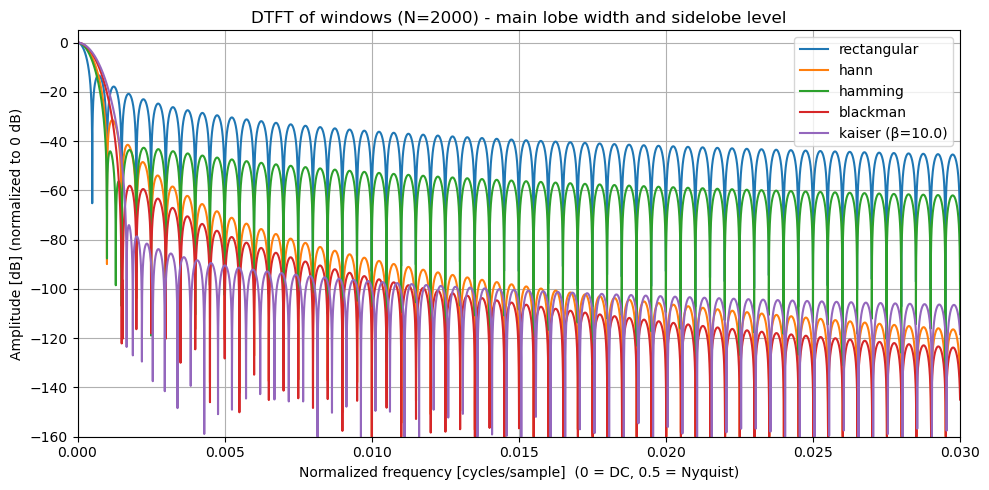

Window                Max sidelobe [dB]  Main lobe width
rectangular                       -2.2 dB   ≈ 0.0004 cycles/sample (2 × first zero)
hann                              -0.8 dB   ≈ 0.0004 cycles/sample (2 × first zero)
hamming                           -1.0 dB   ≈ 0.0004 cycles/sample (2 × first zero)
blackman                          -0.6 dB   ≈ 0.0004 cycles/sample (2 × first zero)
kaiser(β=10.0)                    -0.6 dB   ≈ 0.0004 cycles/sample (2 × first zero)


In [16]:
# Window spectrum computed on N = 2000 samples with large zero-padding
N_win = 2000
nfft_win = 2 ** 20   # large zero-padding → smooth DTFT curve

plt.figure(figsize=(10, 5))
for nm in win_list:
    w = make_window(nm, N_win, beta=beta)
    W = np.fft.rfft(w, n=nfft_win)
    freq_norm = np.fft.rfftfreq(nfft_win)  # cycles/sample ∈ [0, 0.5]
    W_db = db(np.abs(W) / np.max(np.abs(W)))
    lbl = nm if nm != "kaiser" else f"kaiser (β={beta})"
    plt.plot(freq_norm, W_db, label=lbl)

plt.grid(True)
plt.xlabel("Normalized frequency [cycles/sample]  (0 = DC, 0.5 = Nyquist)")
plt.ylabel("Amplitude [dB] (normalized to 0 dB)")
plt.title(f"DTFT of windows (N={N_win}) - main lobe width and sidelobe level")
plt.xlim(0, 0.03)
plt.ylim(-160, 5)
plt.legend()
plt.tight_layout()
plt.show()

# Table: highest sidelobe level and approximate main lobe width
print(f"{'Window':<20} {'Max sidelobe [dB]':>18}  {'Main lobe width':}")
for nm in win_list:
    w = make_window(nm, N_win, beta=beta)
    W = np.fft.rfft(w, n=nfft_win)
    W_abs = np.abs(W) / np.max(np.abs(W))
    freqs = np.fft.rfftfreq(nfft_win)
    peak_idx = np.argmax(W_abs)
    after_peak = W_abs[peak_idx:]
    first_min_idx = peak_idx + np.argmin(after_peak[:200])
    main_lobe_half_bw = freqs[first_min_idx]
    sidelobe_region = W_abs[first_min_idx + 1:]
    max_sl = 20*np.log10(np.max(sidelobe_region)) if len(sidelobe_region) > 0 else float('nan')
    lbl = nm if nm != "kaiser" else f"kaiser(β={beta})"
    print(f"{lbl:<20} {max_sl:>17.1f} dB   ≈ {main_lobe_half_bw*2:.4f} cycles/sample (2 × first zero)")


## Interpretation of Results

### Task Parameters - Summary

| Component | Frequency | Alias (after 800 Hz sampling) | Amplitude | Relative level |
|---|---|---|---|---|
| $x_1$ | 600.00 Hz | **200.00 Hz** | 3.0 | 0 dB |
| $x_2$ | 600.25 Hz | **199.75 Hz** | 0.3 | −20 dB |
| $x_3$ | 599.75 Hz | **200.25 Hz** | 0.03 | −40 dB |

FFT resolution: $df = f_s / N = 800 / 2000 = 0.4$ Hz.  
Spacing between components: $\Delta f = 0.25$ Hz $< df$ → **components do not fall into separate DFT bins** without additional zero-padding.

---

### Detectability of Weak Components (dynamic range) vs. Frequency Resolution

#### Which window best detects weak components next to a strong one?

The strong component $f_1$ generates sidelobes that may obscure $x_2$ (−20 dB) and $x_3$ (−40 dB).  
Windows with **low sidelobe levels** reduce the noise/leakage floor and allow weak components to be recovered:

- **Blackman** - sidelobes approx. **−74 dB**; effectively reveals $x_3$ (−40 dB).
- **Kaiser (β = 10)** - sidelobes approx. **−90 dB**; best suppression, $x_3$ clearly visible.
- **Hamming** - sidelobes ~−43 dB; sufficient to detect $x_2$, but $x_3$ may be hidden.
- **Hann** - sidelobes ~−32 dB; $x_3$ is usually buried under leakage.
- **Rectangular** - sidelobes only ~−13 dB; leakage from $f_1$ dominates and masks both weaker components.

**Conclusion:** **Kaiser (β=10)** and **Blackman** windows are best for detecting weak components.

#### Which window best resolves close frequencies?

The separation of the three components `599.75 / 600.00 / 600.25` Hz (alias: `200.25 / 200.00 / 199.75`) is 0.25 Hz, less than $df = 0.4$ Hz.  
A narrow main lobe means closer peaks can potentially be distinguished:

- **Rectangular** - narrowest main lobe (≈ $2/N$ cycles/sample ≈ $2 \cdot df$); in practice shows an attempt at separation, but high sidelobes distort the result.
- **Hann / Hamming** - main lobe width ~$4/N$; peaks of such close components merge.
- **Blackman / Kaiser (β=10)** - widest main lobe (~$6/N$ to $8/N$); three very close peaks may merge completely.

**Conclusion:** no window can fully resolve components separated by 0.25 Hz when $df = 0.4$ Hz.  
Resolution can only be improved by **increasing N** (longer observation).

---

### Trade-off

| Property | Narrow main lobe (rect) | Low sidelobe level (Kaiser/Blackman) |
|---|---|---|
| Frequency resolution | **better** | worse |
| Detectability of weak components | worse | **better** |
| Sidelobe level | high (~−13 dB) | low (−74 to −90 dB) |

**For Variant 6** (strong-weak ratio down to −40 dB, spacing < df) the priority is **dynamic range** → recommended: **Kaiser (β=10)** or **Blackman**.
